In [2]:
import requests
import pandas as pd
import seaborn as sns

BASE_URL = "https://archive-api.open-meteo.com/v1/era5"

In [3]:
def get_open_meteo_hourly_data(
    latitude=42.50729,
    longitude=1.53414,
    start_date="2022-01-01",
    end_date="2022-12-31",
    api_parameter="temperature_2m",
):
    url = f"{BASE_URL}?latitude={latitude}&longitude={longitude}&start_date={
        start_date}&end_date={end_date}&hourly={api_parameter}"
    data = requests.get(url).json()
    return data


def open_meteo_data_to_dataframe(data: dict):
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df["month"] = df["time"].dt.month
    df["day"] = df["time"].dt.day
    return df

In [4]:
data = get_open_meteo_hourly_data()
df = open_meteo_data_to_dataframe(data)
df

,time,temperature_2m,month,day
0,2022-01-01 00:00:00,14.5,1,1
1,2022-01-01 01:00:00,12.7,1,1
2,2022-01-01 02:00:00,9.9,1,1
3,2022-01-01 03:00:00,7.5,1,1
4,2022-01-01 04:00:00,6.4,1,1
...,...,...,...,...
8755,2022-12-31 19:00:00,10.3,12,31
8756,2022-12-31 20:00:00,10.3,12,31
8757,2022-12-31 21:00:00,6.6,12,31
8758,2022-12-31 22:00:00,7.2,12,31


In [5]:
df_cities = pd.read_csv("european_cities.csv", sep=";")
df_cities = df_cities[
    (df_cities["population"] >= 10_000)
    & ((df_cities["countrycode"] == "CH") | (df_cities["countrycode"] == "NL"))
]
print(df_cities.shape)
df_cities.head()

(314, 10)


,geonameid,name,latitude,longitude,countrycode,population,timezone,admin1code,alternatenames,continentcode
423,2657896,Zürich,47.36667,8.55000,CH,341730,Europe/Zurich,ZH,"['Cirihe', 'Cirikh', 'Ciurichas', 'Cjurikh', '...",EU
424,2657908,Zug,47.17242,8.51745,CH,23435,Europe/Zurich,ZG,"['Cug', 'Tugium', 'ZLM', 'Zoug', 'Zug', 'Zugo'...",EU
425,2657941,Yverdon-les-Bains,46.77852,6.64115,CH,23702,Europe/Zurich,VD,"['Aebura', 'Eburodunum', 'Iverdon le Ben', 'Iv...",EU
426,2657970,Winterthur,47.50564,8.72413,CH,91908,Europe/Zurich,ZH,"['Eulachstadt', 'Vintehrtur', 'Vintertour', 'V...",EU
427,2657996,Wil,47.46152,9.04552,CH,23955,Europe/Zurich,SG,"['Vil', ""Vil'"", 'Vilis', 'Wil', 'Wil SG', 'wei...",EU


In [6]:
def get_data_for_city(city: pd.Series):
    data = get_open_meteo_hourly_data(
        latitude=city["latitude"], longitude=city["longitude"]
    )
    df = open_meteo_data_to_dataframe(data)
    df["name"] = city["name"]
    df["latitude"] = city["latitude"]
    df["longitude"] = city["longitude"]
    df["countrycode"] = city["countrycode"]
    df["population"] = city["population"]
    df["continentcode"] = city["continentcode"]
    return df

In [7]:
get_data_for_city(df_cities.iloc[0])

,time,temperature_2m,month,day,name,latitude,longitude,countrycode,population,continentcode
0,2022-01-01 00:00:00,3.5,1,1,Zürich,47.36667,8.55,CH,341730,EU
1,2022-01-01 01:00:00,2.9,1,1,Zürich,47.36667,8.55,CH,341730,EU
2,2022-01-01 02:00:00,5.9,1,1,Zürich,47.36667,8.55,CH,341730,EU
3,2022-01-01 03:00:00,2.7,1,1,Zürich,47.36667,8.55,CH,341730,EU
4,2022-01-01 04:00:00,1.5,1,1,Zürich,47.36667,8.55,CH,341730,EU
...,...,...,...,...,...,...,...,...,...,...
8755,2022-12-31 19:00:00,7.1,12,31,Zürich,47.36667,8.55,CH,341730,EU
8756,2022-12-31 20:00:00,6.6,12,31,Zürich,47.36667,8.55,CH,341730,EU
8757,2022-12-31 21:00:00,5.9,12,31,Zürich,47.36667,8.55,CH,341730,EU
8758,2022-12-31 22:00:00,5.5,12,31,Zürich,47.36667,8.55,CH,341730,EU


In [8]:
# df_results = pd.concat(get_data_for_city(row)
#                        for _, row in df_cities.iterrows())

df_results = pd.concat(df_cities.apply(get_data_for_city, axis=1).tolist())

In [9]:
df_results

,time,temperature_2m,month,day,name,latitude,longitude,countrycode,population,continentcode
0,2022-01-01 00:00:00,3.5,1,1,Zürich,47.36667,8.55000,CH,341730,EU
1,2022-01-01 01:00:00,2.9,1,1,Zürich,47.36667,8.55000,CH,341730,EU
2,2022-01-01 02:00:00,5.9,1,1,Zürich,47.36667,8.55000,CH,341730,EU
3,2022-01-01 03:00:00,2.7,1,1,Zürich,47.36667,8.55000,CH,341730,EU
4,2022-01-01 04:00:00,1.5,1,1,Zürich,47.36667,8.55000,CH,341730,EU
...,...,...,...,...,...,...,...,...,...,...
8755,2022-12-31 19:00:00,15.2,12,31,Ypenburg,52.04098,4.36981,NL,30000,EU
8756,2022-12-31 20:00:00,15.0,12,31,Ypenburg,52.04098,4.36981,NL,30000,EU
8757,2022-12-31 21:00:00,15.0,12,31,Ypenburg,52.04098,4.36981,NL,30000,EU
8758,2022-12-31 22:00:00,14.5,12,31,Ypenburg,52.04098,4.36981,NL,30000,EU


In [10]:
df_results.groupby(["name", "month"])["temperature_2m"].mean()

name                           month
's-Gravenzande                 1         6.080108
                               2         6.887946
                               3         7.440054
                               4         9.543472
                               5        13.411290
                                          ...    
Zürich (Kreis 9) / Altstetten  8        20.945833
                               9        14.688194
                               10       13.815726
                               11        7.185139
                               12        2.488978
Name: temperature_2m, Length: 3756, dtype: float64

In [13]:
df_results.groupby(["name", "month"])["temperature_2m"].mean().reset_index().to_csv(
    "temperature_by_city_month.csv", index=False
)

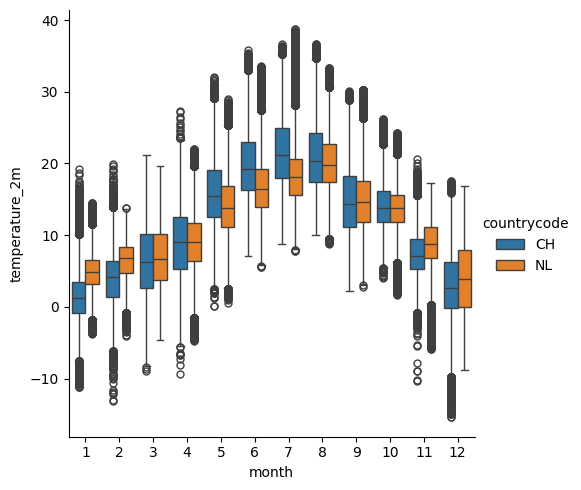

In [12]:
g = sns.catplot(
    data=df_results,
    x="month",
    y="temperature_2m",
    hue="countrycode",
    kind="box",
)